# TFT Training — Cáceres Solar Forecast

This notebook trains a Temporal Fusion Transformer (TFT) on the preprocessed Cáceres solar
generation dataset. Hyperparameters are tuned using Optuna with a TPE sampler.

All hyperparameter selection uses validation data only.
The test set is evaluated in a separate notebook (`tft_evaluation.ipynb`) exactly once.

**Pipeline steps:**

| # | Step | Purpose |
|---|---|---|
| 0 | Imports & setup | Libraries, GPU detection, random seed |
| 1 | Configuration | Sequence lengths, feature lists, denorm params |
| 2 | Data loading | Load CSVs, add time_idx and group_id |
| 3 | TimeSeriesDataSet construction | Disable internal scaling, classify features |
| 4 | Learning rate finder | Establish LR range before tuning |
| 5 | Hyperparameter tuning | Optuna TPE, 25 trials, 6 hyperparameters |
| 6 | Final model training | Best HPs, early stopping, checkpointing |
| 7 | Validation evaluation | Denormalized metrics (RMSE, MAE, R²) |
| 8 | Save artifacts | Model, study, metrics, predictions |

## Step 0 — Imports & setup

In [1]:
import os, json, warnings, pickle
import numpy as np
import numpy._core.multiarray
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.tuner import Tuner

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss, MAE, RMSE
from pytorch_forecasting.data.encoders import TorchNormalizer

import optuna
from optuna.samplers import TPESampler

# Restore pre-PyTorch-2.6 torch.load behavior (weights_only=False by default)
# Needed because Lightning's LR finder and checkpoint restore store pytorch-forecasting
# objects that aren't in the safe globals allowlist. Safe here — we only load our own checkpoints.
import functools
_orig_torch_load = torch.load
@functools.wraps(_orig_torch_load)
def _patched_torch_load(*args, **kwargs):
    if kwargs.get('weights_only') is None:
        kwargs['weights_only'] = False
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_torch_load

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
pl.seed_everything(42)

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Seed set to 42


PyTorch 2.7.1+cu126
CUDA available: True
GPU: NVIDIA L4


In [2]:
%pip install torchmetrics

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.4.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.2 MB/s eta 0:00:00
Using cached numpy-2.4.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
Using cached packaging-26.0-py3-none-any.whl (74 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 90.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 155.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 131.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 168.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 181.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━

## Step 1 — Configuration

In [2]:
# ── Paths ──
DATA_DIR  = os.path.join(os.getcwd(), 'data')
MODEL_DIR = os.path.join(os.getcwd(), 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Sequence lengths ──
MAX_ENCODER_LENGTH    = 168   # 7 days of hourly history
MAX_PREDICTION_LENGTH = 24    # 1-day-ahead forecast

# ── Feature classification ──
KNOWN_FUTURE = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi',
]
OBSERVED = [
    'dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa',
    'total_precip_mm', 'ssrd_wm2', 'strd_wm2', 'kt', 'dewpoint_depression_C',
]
TARGET = 'pv_generation_mwh'

# ── Denormalization parameters ──
with open(os.path.join(DATA_DIR, 'preprocessing_params.json')) as f:
    pp = json.load(f)
TARGET_MEAN = pp['target_mean']
TARGET_STD  = pp['target_std']

print(f"Encoder: {MAX_ENCODER_LENGTH}h ({MAX_ENCODER_LENGTH//24}d)")
print(f"Prediction: {MAX_PREDICTION_LENGTH}h")
print(f"Known future features: {len(KNOWN_FUTURE)}")
print(f"Observed features: {len(OBSERVED)}")
print(f"Target denorm: z * {TARGET_STD:.4f} + {TARGET_MEAN:.4f}")

Encoder: 168h (7d)
Prediction: 24h
Known future features: 9
Observed features: 8
Target denorm: z * 739.4788 + 554.9327


## Step 2 — Load data & prepare for TimeSeriesDataSet

In [3]:
# ── Load CSVs ──
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc')
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'val_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc')

print(f"Train: {len(train_df):,} rows  {train_df.index[0]} -> {train_df.index[-1]}")
print(f"Val:   {len(val_df):,} rows   {val_df.index[0]} -> {val_df.index[-1]}")

# ── Verify no NaN ──
assert train_df.isna().sum().sum() == 0, "NaN in training data"
assert val_df.isna().sum().sum() == 0, "NaN in validation data"

# ── Add time_idx: continuous integer across both splits ──
train_df = train_df.reset_index()
val_df   = val_df.reset_index()

train_df['time_idx'] = np.arange(len(train_df))
val_df['time_idx']   = np.arange(len(train_df), len(train_df) + len(val_df))

# ── Add constant group_id (single time series) ──
train_df['group_id'] = '0'
val_df['group_id']   = '0'

# ── Verify continuity ──
assert train_df['time_idx'].iloc[-1] + 1 == val_df['time_idx'].iloc[0], \
    "time_idx not continuous across train/val boundary"

print(f"\ntime_idx range — train: [0, {train_df['time_idx'].max()}], "
      f"val: [{val_df['time_idx'].min()}, {val_df['time_idx'].max()}]")
print(f"Columns: {list(train_df.columns)}")

Train: 17,544 rows  2023-01-01 00:00:00 -> 2024-12-31 23:00:00
Val:   4,344 rows   2025-01-01 00:00:00 -> 2025-06-30 23:00:00

time_idx range — train: [0, 17543], val: [17544, 21887]
Columns: ['datetime_utc', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi', 'dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa', 'total_precip_mm', 'ssrd_wm2', 'strd_wm2', 'kt', 'dewpoint_depression_C', 'pv_generation_mwh', 'time_idx', 'group_id']


## Step 3 — Construct TimeSeriesDataSet

The preprocessed data is already z-score standardized (train-set statistics applied to all splits).
`TimeSeriesDataSet` normally applies its own per-window normalization — we disable this by setting
`target_normalizer=None` and passing no scalers, to avoid double-normalization.

In [4]:
# ── Training dataset ──
training_dataset = TimeSeriesDataSet(
    train_df,
    time_idx='time_idx',
    target=TARGET,
    group_ids=['group_id'],

    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    min_encoder_length=MAX_ENCODER_LENGTH,

    time_varying_known_reals=KNOWN_FUTURE,
    time_varying_unknown_reals=OBSERVED,

    target_normalizer=None,
    scalers={col: None for col in KNOWN_FUTURE + OBSERVED},

    add_relative_time_idx=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

print(f"Training dataset: {len(training_dataset)} samples")
print(f"Encoder length: {training_dataset.max_encoder_length}")
print(f"Prediction length: {training_dataset.max_prediction_length}")

Training dataset: 17353 samples
Encoder length: 168
Prediction length: 24


In [5]:
# ── Validation dataset ──
# Provide encoder context from the training tail.
# ignore_index=True gives a clean monotonic integer index — required because
# train_df.iloc[-168:] has index 17376-17543 and val_df has index 0-4343,
# so without it the concat index is non-monotonic and PyTorch Forecasting
# silently produces only 1 valid window instead of ~4321.
# min_prediction_idx is not needed: the context slice starts exactly
# MAX_ENCODER_LENGTH steps before val_df, so the first valid prediction
# window lands at val_df['time_idx'].min() automatically.
val_with_context = pd.concat([
    train_df.iloc[-MAX_ENCODER_LENGTH:],
    val_df
], ignore_index=True)

val_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    val_with_context,
    stop_randomization=True,
)

print(f"Validation dataset: {len(val_dataset)} samples")
assert len(val_dataset) > 100, \
    f"Val dataset too small ({len(val_dataset)}): check concat/context construction"

Validation dataset: 4321 samples


In [6]:
# ── DataLoaders ──
BATCH_SIZE = 64

train_dataloader = training_dataset.to_dataloader(
    train=True, batch_size=BATCH_SIZE, num_workers=2
)
val_dataloader = val_dataset.to_dataloader(
    train=False, batch_size=BATCH_SIZE, num_workers=2
)

# Sanity check: inspect one batch
x, y = next(iter(train_dataloader))
print(f"Batch shapes:")
print(f"  Encoder cont. inputs: {x['encoder_cont'].shape}")
print(f"  Decoder cont. inputs: {x['decoder_cont'].shape}")
print(f"  Target:               {y[0].shape}")

Batch shapes:
  Encoder cont. inputs: torch.Size([64, 168, 19])
  Decoder cont. inputs: torch.Size([64, 24, 19])
  Target:               torch.Size([64, 24])


## Step 4 — Learning rate finder

Run Lightning's LR finder to establish a reasonable learning rate range before HP tuning.
This prevents wasting Optuna trials on suboptimal LR regions.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at /home/liw899/ML-solar-forecast/caceres_analysis/.lr_find_6247f0da-5673-451e-ac4a-640a1e8b5371.ckpt
Restored all states from the checkpoint at /home/liw899/ML-solar-forecast/caceres_analysis/.lr_find_6247f0da-5673-451e-ac4a-640a1e8b5371.ckpt
Learning rate set to 8.31763771102671e-05


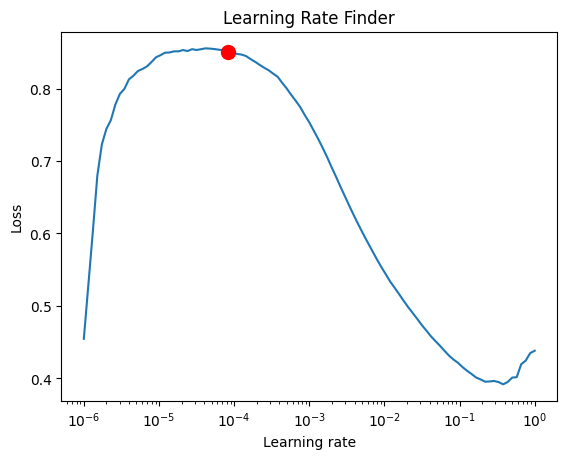

Suggested LR: 0.000083


In [7]:
# Quick model with default HPs for LR finding
tft_tmp = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=0.001,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
    optimizer='adam',
)

trainer_tmp = pl.Trainer(
    accelerator='auto',
    gradient_clip_val=0.1,
    max_epochs=3,
)

tuner = Tuner(trainer_tmp)
lr_finder = tuner.lr_find(
    tft_tmp,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    min_lr=1e-6,
    max_lr=1.0,
    num_training=100,
)

fig = lr_finder.plot(suggest=True)
plt.title("Learning Rate Finder")
plt.show()

suggested_lr = lr_finder.suggestion()
print(f"Suggested LR: {suggested_lr:.6f}")

del tft_tmp, trainer_tmp
torch.cuda.empty_cache()

## Step 5 — Hyperparameter tuning (Optuna, TPE, 25 trials)

Following the reference paper's approach (NNI with TPE) but using Optuna's TPE sampler
for simpler integration with pytorch-forecasting.

| Hyperparameter | Search Space | Rationale |
|---|---|---|
| `hidden_size` | {16, 32, 64, 128} | Model capacity; 128 already large for 17k samples |
| `lstm_layers` | {1, 2} | Temporal processing depth |
| `attention_head_size` | {1, 2, 4} | Multi-head interpretable attention |
| `dropout` | Uniform(0.1, 0.4) | Primary regularization lever |
| `hidden_continuous_size` | {8, 16, 32} | Continuous variable processing width |
| `learning_rate` | LogUniform(1e-4, 1e-2) | Guided by LR finder |

Per-trial: max 20 epochs, early stopping patience 3 on val_loss.

In [8]:
def optuna_objective(trial):
    """Single Optuna trial: sample HPs, train TFT, return val_loss."""

    # ── Sample hyperparameters ──
    hidden_size            = trial.suggest_categorical('hidden_size', [16, 32, 64, 128])
    lstm_layers            = trial.suggest_int('lstm_layers', 1, 2)
    attention_head_size    = trial.suggest_categorical('attention_head_size', [1, 2, 4])
    dropout                = trial.suggest_float('dropout', 0.1, 0.4)
    hidden_continuous_size = trial.suggest_categorical('hidden_continuous_size', [8, 16, 32])
    learning_rate          = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # ── Create model ──
    tft = TemporalFusionTransformer.from_dataset(
        training_dataset,
        hidden_size=hidden_size,
        lstm_layers=lstm_layers,
        attention_head_size=attention_head_size,
        dropout=dropout,
        hidden_continuous_size=hidden_continuous_size,
        learning_rate=learning_rate,
        loss=QuantileLoss(),
        optimizer='adam',
        reduce_on_plateau_patience=3,
        output_size=7,
    )

    # ── Trainer (lightweight for tuning) ──
    trainer = pl.Trainer(
        max_epochs=10,  # 20 was gonna take way too long
        accelerator='auto',
        gradient_clip_val=0.1,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=3, mode='min', verbose=False),
        ],
        enable_model_summary=False,
        enable_progress_bar=False,
        enable_checkpointing=False,
        logger=False,
    )

    try:
        trainer.fit(tft, train_dataloaders=train_dataloader,
                    val_dataloaders=val_dataloader)
        val_loss = trainer.callback_metrics['val_loss'].item()
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        val_loss = float('inf')
    finally:
        torch.cuda.empty_cache()

    return val_loss

In [9]:
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    study_name='tft_caceres_hp_tuning',
)

study.optimize(
    optuna_objective,
    n_trials=15,    # 25 was also unnecessarily long for this
    show_progress_bar=True,
    gc_after_trial=True,
)

print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best val_loss: {study.best_value:.6f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-03-09 19:28:59,475] A new study created in memory with name: tft_caceres_hp_tuning


  0%|          | 0/15 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[I 2026-03-09 19:29:37,686] Trial 0 finished with value: 0.15919621288776398 and parameters: {'hidden_size': 32, 'lstm_layers': 1, 'attention_head_size': 4, 'dropout': 0.2803345035229627, 'hidden_continuous_size': 32, 'learning_rate': 0.004622589001020831}. Best is trial 0 with value: 0.15919621288776398.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

[I 2026-03-09 20:14:17,670] Trial 12 finished with value: 0.1492403894662857 and parameters: {'hidden_size': 16, 'lstm_layers': 2, 'attention_head_size': 2, 'dropout': 0.3358224312588778, 'hidden_continuous_size': 8, 'learning_rate': 0.009904603756005017}. Best is trial 8 with value: 0.13797485828399658.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[I 2026-03-09 20:17:36,418] Trial 13 finished with value: 0.15746226906776428 and parameters: {'hidden_size': 64, 'lstm_layers': 1, 'attention_head_size': 4, 'dropout': 0.3638167066740923, 'hidden_continuous_size': 8, 'learning_rate': 0.0020200513082957805}. Best is trial 8 with value: 0.13797485828399658.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[I 2026-03-09 20:20:01,403] Trial 14 finished with value: 0.15551213920116425 and parameters: {'hidden_size': 16, 'lstm_layers': 1, 'attention_head_size': 2, 'dropout': 0.3021592446821507, 'hidden_continuous_size': 32, 'learning_rate': 0.00205911191829318}. Best is trial 8 with value: 0.13797485828399658.

Best trial: #8
Best val_loss: 0.137975
Best params:
  hidden_size: 16
  lstm_layers: 1
  attention_head_size: 2
  dropout: 0.378909295702772
  hidden_continuous_size: 32
  learning_rate: 0.004048966222584676


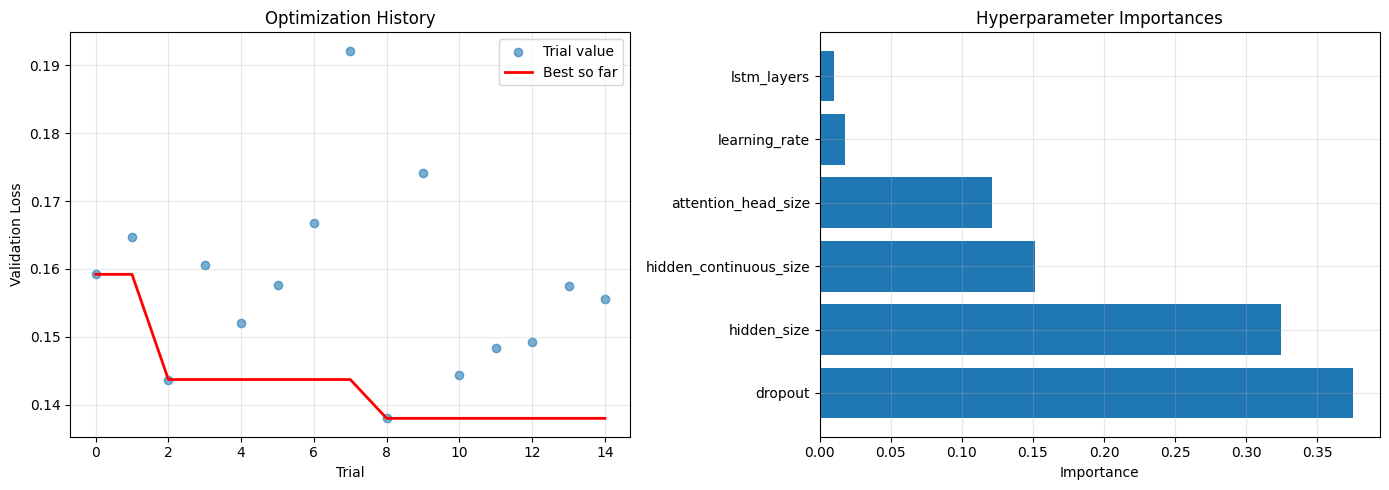

In [10]:
# ── Visualize the HP study ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trial_numbers = [t.number for t in study.trials if t.value is not None and t.value < float('inf')]
trial_values  = [t.value for t in study.trials if t.value is not None and t.value < float('inf')]
best_so_far   = np.minimum.accumulate(trial_values)

axes[0].scatter(trial_numbers, trial_values, alpha=0.6, label='Trial value')
axes[0].plot(trial_numbers, best_so_far, 'r-', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Optimization History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter importances (manual: use trial values)
param_names = list(study.best_params.keys())
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()))
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importances')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6 — Train final model with best HPs

Full training with the best hyperparameters from the Optuna study.
Longer training budget (max 75 epochs) with patience 10 and model checkpointing.

In [11]:
best = study.best_params

tft_final = TemporalFusionTransformer.from_dataset(
    training_dataset,
    hidden_size=best['hidden_size'],
    lstm_layers=best['lstm_layers'],
    attention_head_size=best['attention_head_size'],
    dropout=best['dropout'],
    hidden_continuous_size=best['hidden_continuous_size'],
    learning_rate=best['learning_rate'],
    loss=QuantileLoss(),
    optimizer='adam',
    reduce_on_plateau_patience=5,
    output_size=7,
)

print(f"Model parameters: {sum(p.numel() for p in tft_final.parameters()):,}")
print(f"Best HPs: {best}")

Model parameters: 70,707
Best HPs: {'hidden_size': 16, 'lstm_layers': 1, 'attention_head_size': 2, 'dropout': 0.378909295702772, 'hidden_continuous_size': 32, 'learning_rate': 0.004048966222584676}


In [12]:
checkpoint_callback = ModelCheckpoint(
    dirpath=MODEL_DIR,
    filename='tft_best',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)

trainer_final = pl.Trainer(
    max_epochs=75,
    accelerator='auto',
    gradient_clip_val=0.1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, mode='min', verbose=True),
        checkpoint_callback,
        LearningRateMonitor(logging_interval='epoch'),
    ],
    log_every_n_steps=50,
)

trainer_final.fit(
    tft_final,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

print(f"\nBest model saved to: {checkpoint_callback.best_model_path}")
print(f"Best val_loss: {checkpoint_callback.best_model_score:.6f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 0      | train | 0    
3  | prescalers                         | ModuleDict                      | 1.2 K  | train | 0    
4  | static_variable_selection          | Varia

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved. New best score: 0.142


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 10 records. Best score: 0.138. Signaling Trainer to stop.



Best model saved to: /home/liw899/ML-solar-forecast/caceres_analysis/models/tft_best.ckpt
Best val_loss: 0.138179


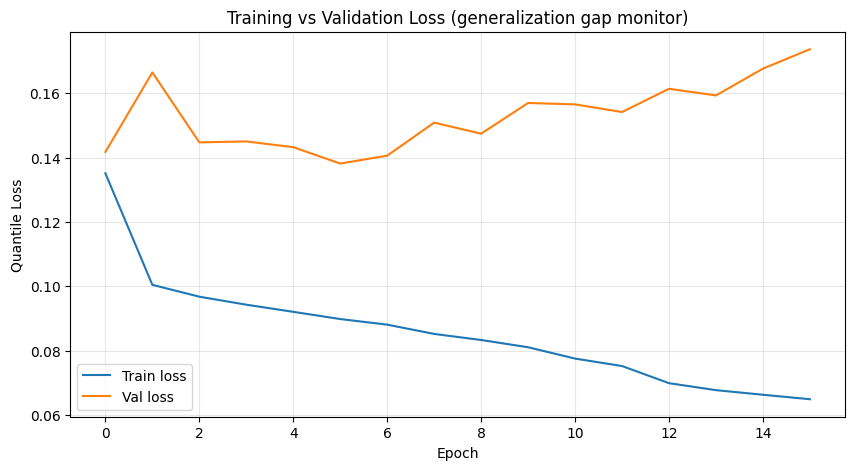

Generalization gap (val_min - train_min): 0.073290


In [13]:
# ── Plot training vs validation loss (generalization gap monitor) ──
train_losses = []
val_losses = []

# Extract from trainer's logged metrics
log_dir = trainer_final.logger.log_dir
metrics_file = os.path.join(log_dir, 'metrics.csv') if log_dir else None

if metrics_file and os.path.exists(metrics_file):
    metrics_df = pd.read_csv(metrics_file)
    # group by epoch and get last value per epoch
    if 'train_loss_epoch' in metrics_df.columns:
        train_loss_per_epoch = metrics_df.dropna(subset=['train_loss_epoch']).groupby('epoch')['train_loss_epoch'].last()
        val_loss_per_epoch = metrics_df.dropna(subset=['val_loss']).groupby('epoch')['val_loss'].last()

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(train_loss_per_epoch.index, train_loss_per_epoch.values, label='Train loss')
        ax.plot(val_loss_per_epoch.index, val_loss_per_epoch.values, label='Val loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Quantile Loss')
        ax.set_title('Training vs Validation Loss (generalization gap monitor)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

        gap = val_loss_per_epoch.min() - train_loss_per_epoch.min()
        print(f"Generalization gap (val_min - train_min): {gap:.6f}")
    else:
        print("Training loss not logged per epoch. Check logger configuration.")
else:
    print("No metrics CSV found. Loss curves unavailable.")

## Step 7 — Validation evaluation

Generate predictions on the validation set and compute metrics on the original MWh scale.
This is the final validation — no further model changes after this point.

In [14]:
def denormalize(z_values):
    """Convert z-score normalized values back to original MWh scale."""
    return z_values * TARGET_STD + TARGET_MEAN

def compute_metrics(actual_mwh, predicted_mwh):
    """Compute RMSE, MAE, R² on original MWh scale."""
    residuals = actual_mwh - predicted_mwh
    mae  = np.abs(residuals).mean()
    rmse = np.sqrt((residuals ** 2).mean())
    ss_res = (residuals ** 2).sum()
    ss_tot = ((actual_mwh - actual_mwh.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    return {'MAE_MWh': float(mae), 'RMSE_MWh': float(rmse), 'R2': float(r2)}

In [15]:
# Load best checkpoint
best_model = TemporalFusionTransformer.load_from_checkpoint(
    checkpoint_callback.best_model_path
)
best_model.eval()

# Predict on validation set
val_predictions = best_model.predict(
    val_dataloader,
    mode='prediction',
    return_x=True,
    return_y=True,
)

val_raw = best_model.predict(
    val_dataloader,
    mode='raw',
    return_x=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

In [16]:
# Extract predictions and actuals
pred_z   = val_predictions.output.cpu().numpy()
actual_z = val_predictions.y[0].cpu().numpy()

# Flatten across all windows and horizons
pred_z_flat   = pred_z.flatten()
actual_z_flat = actual_z.flatten()

# Denormalize
pred_mwh   = denormalize(pred_z_flat)
actual_mwh = denormalize(actual_z_flat)

# Clip negative predictions to 0 (solar generation cannot be negative)
pred_mwh = np.clip(pred_mwh, 0, None)

val_metrics = compute_metrics(actual_mwh, pred_mwh)
print("Validation Metrics (original MWh scale):")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\nValidation quantile loss (normalized): {checkpoint_callback.best_model_score:.6f}")

Validation Metrics (original MWh scale):
  MAE_MWh: 183.2382
  RMSE_MWh: 343.8855
  R2: 0.8299

Validation quantile loss (normalized): 0.138179


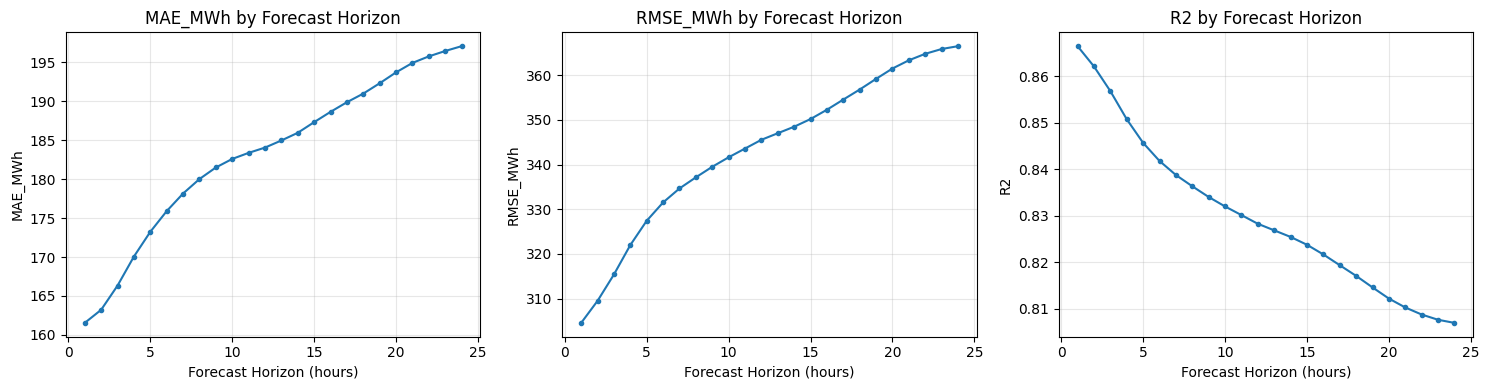

   MAE_MWh   RMSE_MWh       R2  horizon_h
161.545410 304.582733 0.866417          1
163.222748 309.509705 0.862060          2
166.327789 315.406158 0.856754          3
170.057343 321.989868 0.850712          4
173.231964 327.420074 0.845634          5
175.887115 331.515076 0.841744          6
178.145432 334.644806 0.838725          7
180.005142 337.130707 0.836302          8
181.487457 339.491486 0.833999          9
182.585083 341.612915 0.831963         10
183.364349 343.569885 0.830107         11
184.041183 345.526398 0.828239         12
184.954849 346.994690 0.826826         13
185.938324 348.453156 0.825410         14
187.307053 350.168945 0.823727         15
188.627258 352.249329 0.821645         16
189.865509 354.526184 0.819332         17
190.971970 356.767822 0.817040         18
192.297043 359.155945 0.814563         19
193.698792 361.470367 0.812161         20
194.909988 363.306213 0.810248         21
195.748917 364.756531 0.808730         22
196.439026 365.828339 0.807604    

In [17]:
# ── Per-horizon metrics ──
horizon_metrics = []
for h in range(MAX_PREDICTION_LENGTH):
    pred_h   = denormalize(pred_z[:, h])
    actual_h = denormalize(actual_z[:, h])
    pred_h   = np.clip(pred_h, 0, None)
    m = compute_metrics(actual_h, pred_h)
    m['horizon_h'] = h + 1
    horizon_metrics.append(m)

horizon_df = pd.DataFrame(horizon_metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE_MWh', 'RMSE_MWh', 'R2']):
    ax.plot(horizon_df['horizon_h'], horizon_df[metric], marker='o', markersize=3)
    ax.set_xlabel('Forecast Horizon (hours)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Forecast Horizon')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(horizon_df.to_string(index=False))

## Step 8 — Save artifacts

In [18]:
# 1. Optuna study (for later analysis / warm-starting)
with open(os.path.join(MODEL_DIR, 'hp_study.pkl'), 'wb') as f:
    pickle.dump(study, f)

# 2. Human-readable HP results
hp_results = {
    'best_trial': study.best_trial.number,
    'best_val_loss': study.best_value,
    'best_params': study.best_params,
    'n_trials': len(study.trials),
    'val_metrics_mwh': val_metrics,
    'sequence_config': {
        'max_encoder_length': MAX_ENCODER_LENGTH,
        'max_prediction_length': MAX_PREDICTION_LENGTH,
    },
    'training_config': {
        'batch_size': BATCH_SIZE,
        'max_epochs_final': 75,
        'early_stopping_patience': 10,
        'gradient_clip_val': 0.1,
        'optimizer': 'adam',
        'loss': 'QuantileLoss',
        'quantiles': [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98],
    },
}

with open(os.path.join(MODEL_DIR, 'hp_study_results.json'), 'w') as f:
    json.dump(hp_results, f, indent=2)

# 3. Validation predictions
val_pred_df = pd.DataFrame({
    'actual_z': actual_z_flat,
    'predicted_z': pred_z_flat,
    'actual_mwh': actual_mwh,
    'predicted_mwh': pred_mwh,
})
val_pred_df.to_csv(os.path.join(MODEL_DIR, 'val_predictions.csv'), index=False)

print("Artifacts saved:")
for f_name in sorted(os.listdir(MODEL_DIR)):
    f_path = os.path.join(MODEL_DIR, f_name)
    if os.path.isfile(f_path):
        size_mb = os.path.getsize(f_path) / 1e6
        print(f"  {f_name}: {size_mb:.1f} MB")

Artifacts saved:
  hp_study.pkl: 0.0 MB
  hp_study_results.json: 0.0 MB
  tft_best.ckpt: 1.5 MB
  val_predictions.csv: 4.4 MB


In [19]:
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"\nBest hyperparameters:")
for k, v in best.items():
    print(f"  {k}: {v}")
print(f"\nValidation metrics (MWh scale):")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\nModel checkpoint: {checkpoint_callback.best_model_path}")
print(f"\nNext step: run tft_evaluation.ipynb for test set evaluation.")

TRAINING COMPLETE

Best hyperparameters:
  hidden_size: 16
  lstm_layers: 1
  attention_head_size: 2
  dropout: 0.378909295702772
  hidden_continuous_size: 32
  learning_rate: 0.004048966222584676

Validation metrics (MWh scale):
  MAE_MWh: 183.2382
  RMSE_MWh: 343.8855
  R2: 0.8299

Model checkpoint: /home/liw899/ML-solar-forecast/caceres_analysis/models/tft_best.ckpt

Next step: run tft_evaluation.ipynb for test set evaluation.
